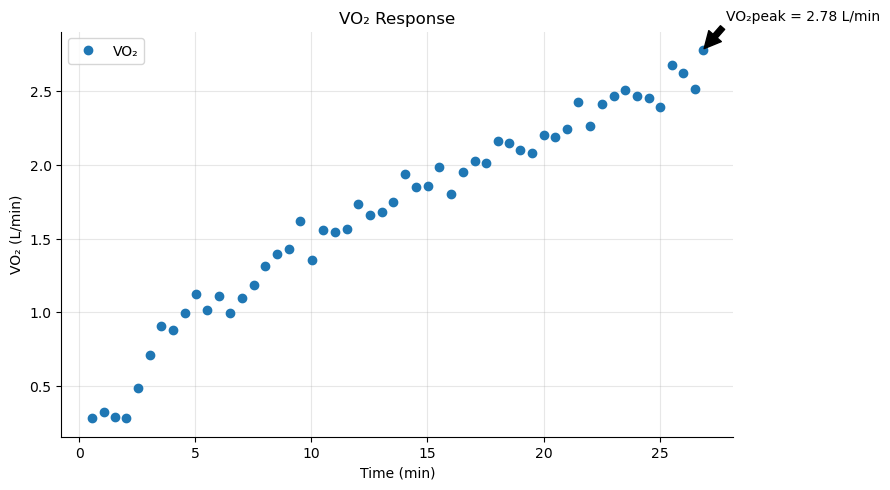

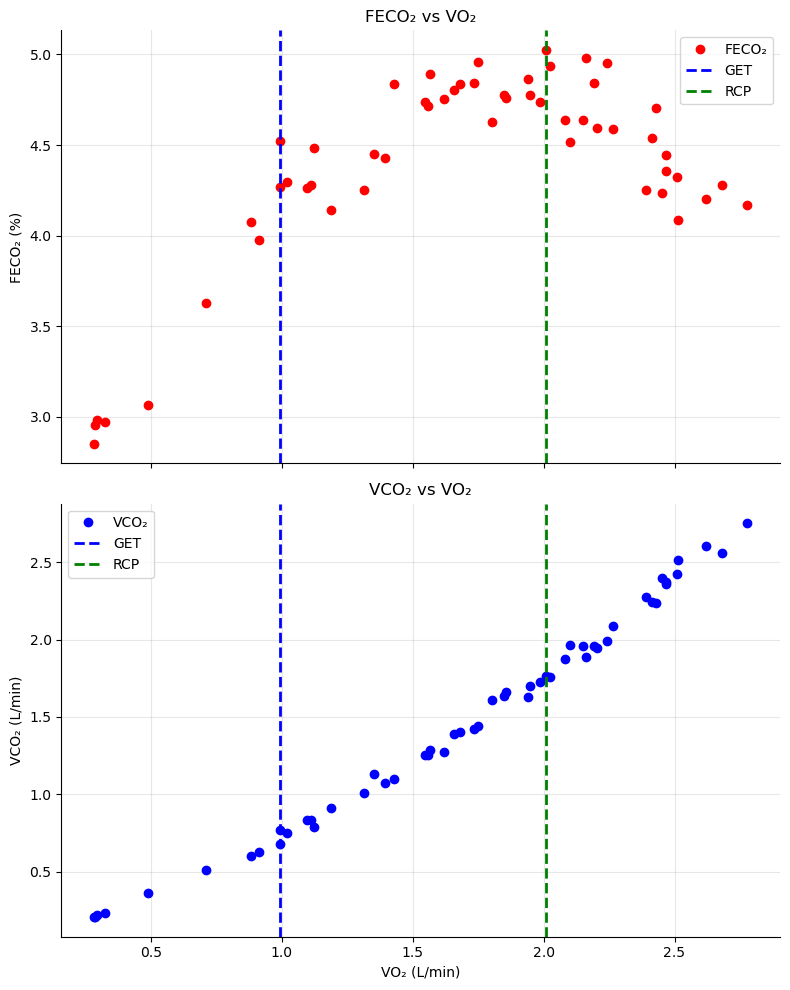

Estimated GET VO2: 0.993 L/min
Estimated RCP VO2: 2.009 L/min


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../input/demo-knes381/subject_1321.csv', header=[0], skiprows=[1,2,3])

df = df.rename(columns={
    'TIME': 'Time(min)',
    'VE/': 'VE/VO2',
    'VE/.1': 'VE/VCO2'})

cols = ['Time(min)', 'VO2', 'VCO2', 'FECO2', 'VE/VO2', 'VE/VCO2']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=cols).reset_index(drop=True)

# Variables 
x = df['VO2']
feco2 = df['FECO2']
vco2 = df['VCO2']
ve_vo2 = df['VE/VO2']
ve_vco2 = df['VE/VCO2']


# Estimate GET

get_index = ve_vo2.idxmin()
GET_VO2 = df.loc[get_index, 'VO2']


# Estimate RCP

rcp_index = ve_vco2.idxmin()
RCP_VO2 = df.loc[rcp_index, 'VO2']

# Peak VO2 
vo2_max = df['VO2'].max()
vo2_max_index = df['VO2'].idxmax()
time_at_vo2max = df.loc[vo2_max_index, 'Time(min)']


# Main VO2 plot

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df['Time(min)'], df['VO2'], 'o', label='VO₂')

ax.annotate(
    f'VO₂peak = {vo2_max:.2f} L/min',
    xy=(time_at_vo2max, vo2_max),
    xytext=(time_at_vo2max + 1, vo2_max + 0.2),
    arrowprops=dict(facecolor='black', shrink=0.05))

ax.spines[['right', 'top']].set_visible(False)
ax.set_title('VO₂ Response')
ax.set_xlabel('Time (min)')
ax.set_ylabel('VO₂ (L/min)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Gas exchange plots

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 10))
fig.subplots_adjust(hspace=0.1)

# FECO2 vs VO2
ax[0].plot(x, feco2, 'o', color='red', label='FECO₂')
ax[0].axvline(GET_VO2, color='blue', linestyle='--', linewidth=2, label='GET')
ax[0].axvline(RCP_VO2, color='green', linestyle='--', linewidth=2, label='RCP')
ax[0].spines[['right', 'top']].set_visible(False)
ax[0].set_ylabel('FECO₂ (%)')
ax[0].set_title('FECO₂ vs VO₂')
ax[0].legend()
ax[0].grid(alpha=0.3)

# VCO2 vs VO2
ax[1].plot(x, vco2, 'o', color='blue', label='VCO₂')
ax[1].axvline(GET_VO2, color='blue', linestyle='--', linewidth=2, label='GET')
ax[1].axvline(RCP_VO2, color='green', linestyle='--', linewidth=2, label='RCP')
ax[1].spines[['right', 'top']].set_visible(False)
ax[1].set_ylabel('VCO₂ (L/min)')
ax[1].set_xlabel('VO₂ (L/min)')
ax[1].set_title('VCO₂ vs VO₂')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("VO2_gas_exchange_plots.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Estimated GET VO2: {GET_VO2:.3f} L/min")
print(f"Estimated RCP VO2: {RCP_VO2:.3f} L/min")